## 07 - Walidacja i Benchmark

## Cel
Ocena skuteczności modeli RF i LSTM w wykrywaniu epizodów 
wysokiej wody. Próg klasyfikacji: 0.5, tolerancja: ±2 dni.

In [1]:
import os
os.chdir('..')
import pandas as pd

from src.data.preprocessing import build_main_df
from src.models.validation import uruchom_benchmark

final = build_main_df()

# Walidacja RF
diagnozy_rf = pd.read_csv(
    'reports/ml/rf/diagnozy_dzienne_rf.csv',
    parse_dates=['Data'],
    index_col='Data'
)
wyniki_rf = uruchom_benchmark(diagnozy_rf, df_poziomy=final, model_name='rf')


[DEBUG] Poprawnie wyznaczony folder projektu: /Users/majamarkiewicz/PycharmProjects/PortCanals

  MODUL 7: BENCHMARK I METRYKI - WALIDACJA MODELU RF
  prog klasyfikacji: 0.5  |  tolerancja: 2 dni

=== Blad poczatku/konca epizodu (onset/offset) ===
  Epizodow rzeczywistych : 60
  Wykrytych              : 33 (55.0%)
  Nieykrytych            : 27 (45.0%)
  Onset error  sr.       : -2.00 dni (std=3.66, mediana=+0.0)
  Offset error sr.       : +0.91 dni (std=2.40, mediana=+0.0)

=== Pokrycie zdarzen (event-level recall) ===
  Epizodow rzeczywistych : 60
  Epizodow predykowanych : 72
  Wykrytych              : 51
  Nieykrytych            : 9
  Event recall           : 0.850

=== Falszywe alarmy (false alarm rate) ===
  Day-level precision    : 0.581
  Day-level FAR          : 0.419   (= 1 - precision)
  Pred. epizodow lacznie : 72
  Falszywe alarmy (ev.)  : 27  (37.5% pred. epizodow)
  Event FAR              : 0.375

=== Blad piku (peak timing / peak magnitude) ===
  Epizodow z dopasowaniem:

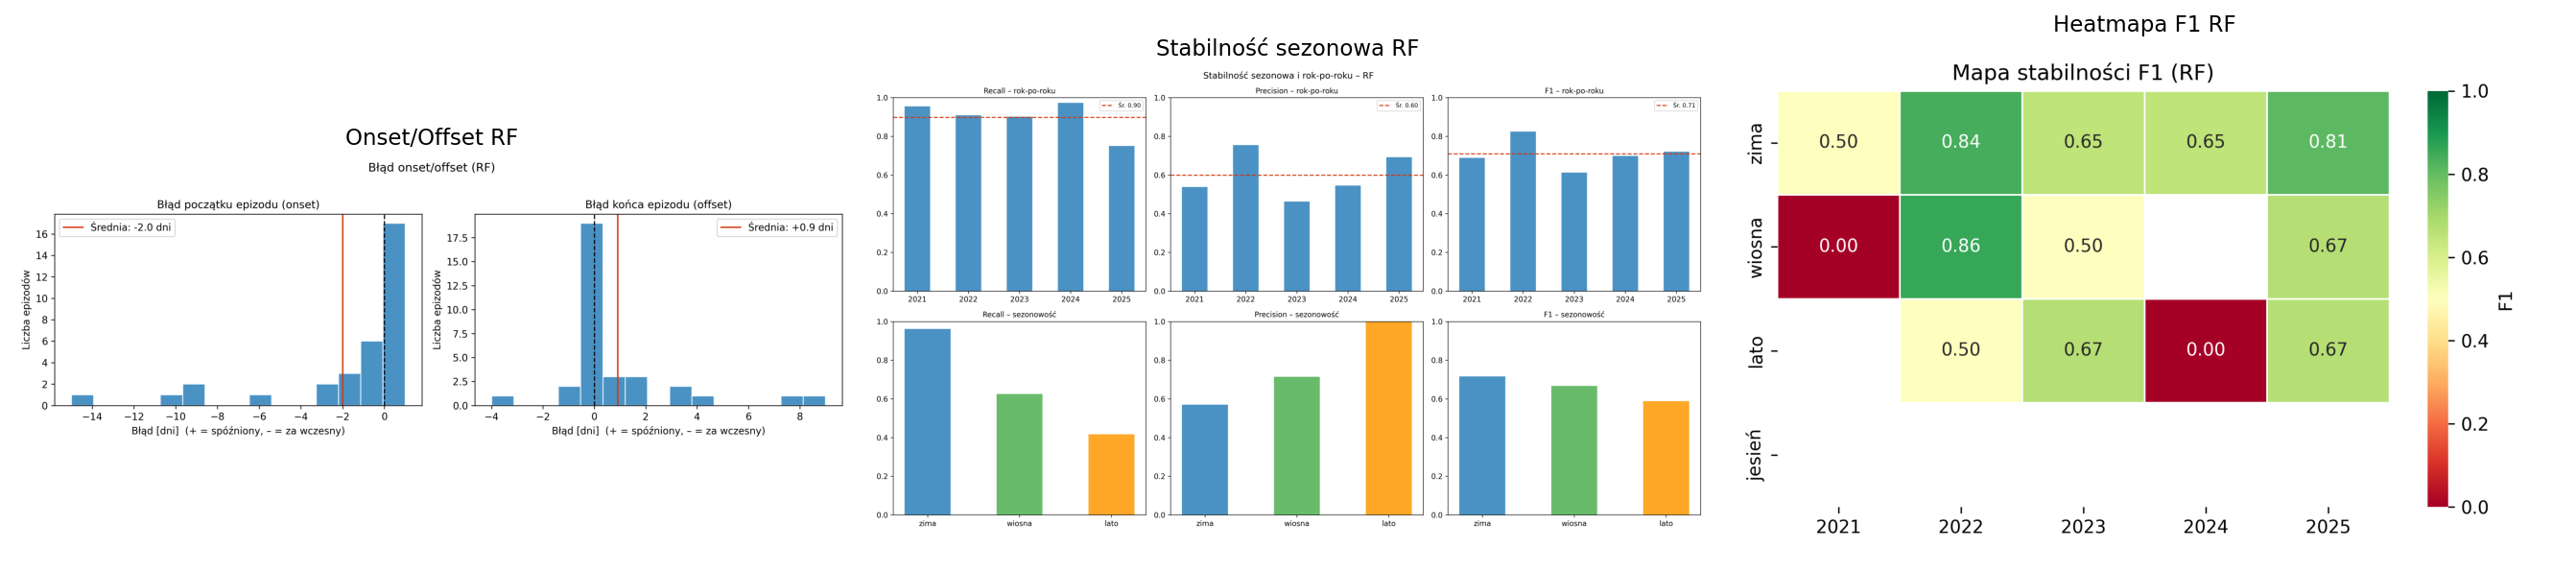

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image, display

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
images_rf = [
    'reports/walidacja/rf/onset_offset_error.png',
    'reports/walidacja/rf/stabilnosc_sezonowa.png',
    'reports/walidacja/rf/heatmapa_stabilnosci_f1.png',
]
titles_rf = ['Onset/Offset RF', 'Stabilność sezonowa RF', 'Heatmapa F1 RF']
for ax, img_path, title in zip(axes, images_rf, titles_rf):
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.savefig('temp_rf.png', dpi=150, bbox_inches='tight')
plt.close()
display(Image('temp_rf.png'))

### Obserwacje z wykresów — RF

- Onset/offset skoncentrowane przy 0 — małe i symetryczne błędy
- Heatmapa F1: zima najstabilniejsza (0.50–0.84), 
  wiosna/lato mają zera — naturalne, bo wezbrania są zimowe
- Błąd piku bardzo skoncentrowany przy 0 — model trafnie 
  wskazuje moment maksimum

### Wnioski RF
- **Event Recall 0.850** — model wykrył 85% rzeczywistych wezbrań
- **Precision 0.581** — 42% fałszywych alarmów
- **Onset error -2.00 dni** — model alarmuje 2 dni za wcześnie
- Najlepszy sezon: zima (recall=0.962, event recall=1.0)
- Najsłabszy sezon: lato (recall=0.417)
- Stabilny rok-po-roku (recall 0.75–0.97)

In [3]:
diagnozy_lstm = pd.read_csv(
    'reports/ml/lstm/diagnozy_dzienne_lstm.csv',
    parse_dates=['Data'],
    index_col='Data'
)

wyniki_lstm = uruchom_benchmark(diagnozy_lstm, df_poziomy=final, model_name='lstm')


  MODUL 7: BENCHMARK I METRYKI - WALIDACJA MODELU LSTM
  prog klasyfikacji: 0.5  |  tolerancja: 2 dni

=== Blad poczatku/konca epizodu (onset/offset) ===
  Epizodow rzeczywistych : 60
  Wykrytych              : 34 (56.7%)
  Nieykrytych            : 26 (43.3%)
  Onset error  sr.       : -7.47 dni (std=9.01, mediana=-3.0)
  Offset error sr.       : +6.03 dni (std=7.64, mediana=+3.0)

=== Pokrycie zdarzen (event-level recall) ===
  Epizodow rzeczywistych : 60
  Epizodow predykowanych : 63
  Wykrytych              : 47
  Nieykrytych            : 13
  Event recall           : 0.783

=== Falszywe alarmy (false alarm rate) ===
  Day-level precision    : 0.413
  Day-level FAR          : 0.587   (= 1 - precision)
  Pred. epizodow lacznie : 63
  Falszywe alarmy (ev.)  : 34  (54.0% pred. epizodow)
  Event FAR              : 0.540

=== Blad piku (peak timing / peak magnitude) ===
  Epizodow z dopasowaniem: 34
  Peak timing error sr.  : -3.74 dni  (std=8.95, mediana=-0.5)
  Peak magnitude error sr

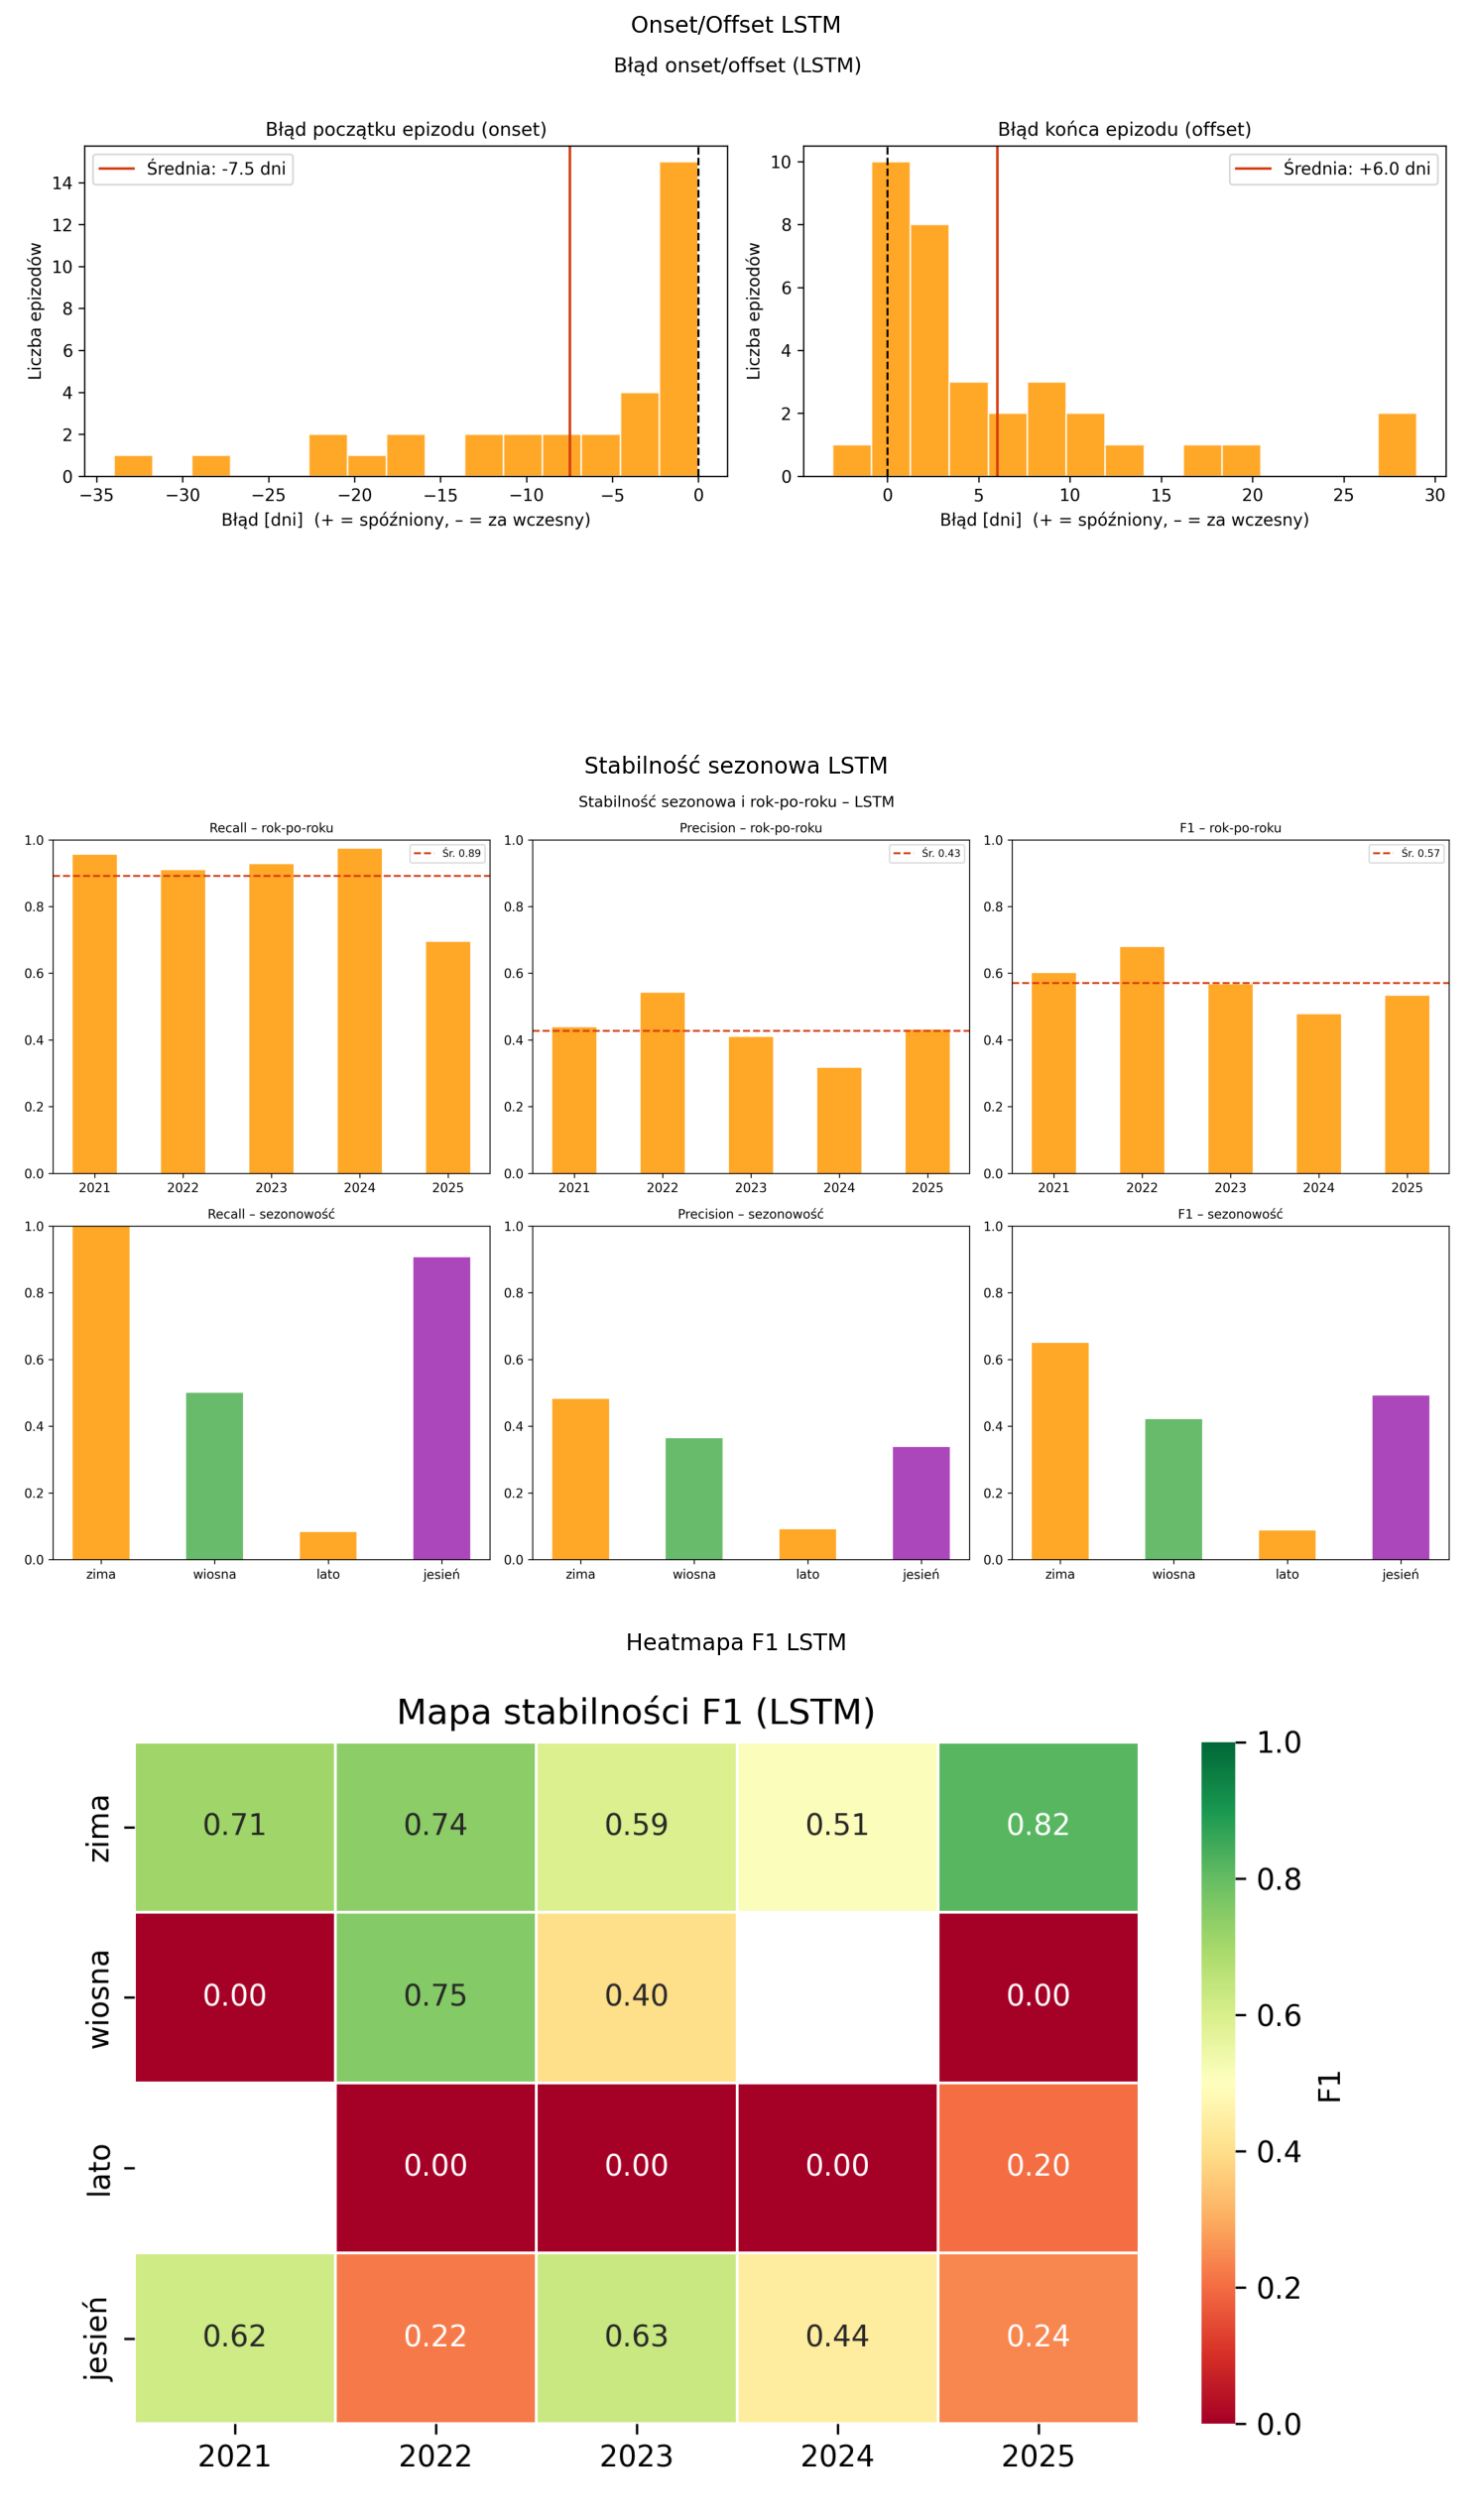

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image, display
fig, axes = plt.subplots(3, 1, figsize=(10, 18))
images_lstm = [
    'reports/walidacja/lstm/onset_offset_error.png',
    'reports/walidacja/lstm/stabilnosc_sezonowa.png',
    'reports/walidacja/lstm/heatmapa_stabilnosci_f1.png',
]
titles_lstm = ['Onset/Offset LSTM', 'Stabilność sezonowa LSTM', 'Heatmapa F1 LSTM']
for ax, img_path, title in zip(axes, images_lstm, titles_lstm):
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.savefig('temp_lstm.png', dpi=150, bbox_inches='tight')
plt.close()
display(Image('temp_lstm.png'))

### Obserwacje z wykresów — LSTM

- Histogramy onset/offset bardzo rozciągnięte (zakres -60 do +50 dni)
  — model włącza alarm nawet 2 miesiące za wcześnie ⚠️
- Heatmapa F1 znacznie bardziej czerwona niż RF
- Lato praktycznie nie działa (F1=0.111 w 2021-2025)
- Jesień niestabilna (0.11–0.52)

### Wnioski LSTM
- **Event Recall 0.817** — niższy niż RF
- **Precision 0.343** — prawie 2x więcej fałszywych alarmów niż RF
- **Onset error -12.94 dni** — duże przesunięcie czasowe !
- Najlepszy sezon: zima (event recall=1.0)
- Niestabilna precyzja rok-po-roku

## Porównanie RF vs LSTM

| Metryka | RF | LSTM |
|---------|-----|------|
| Event recall | **0.850** | 0.817 |
| Precision | **0.581** | 0.343 |
| Event FAR | **0.375** | 0.509 |
| Onset error | **-2.0 dni** | -12.9 dni |
| MAE w epizodzie | **0.305 m** | 0.434 m |

### Obserwacje z wykresu porównawczego RF vs LSTM

- RF wygrywa z LSTM we wszystkich metrykach w każdym roku testowym
- Błąd piku RF skoncentrowany przy 0 — LSTM znacznie bardziej rozrzucony
- LSTM ma tendencję do "rozciągania" epizodów → lawina fałszywych alarmów
- **Rekomendacja: RF** jako model operacyjny